# Python for Astronomy

A hands-on tutorial showcasing five practical use cases for Python in modern cosmological analysis:

1. **Measuring the Hubble Constant** — compute $H_0$ and derived distance–redshift relations with CAMB.
2. **Extracting $\Omega_b$ with BAOs** — constrain the baryon density using Baryon Acoustic Oscillation dilation parameters.
3. **Calibrating Photometric Redshifts** — apply photo-$z$ shift corrections to tomographic $n(z)$ distributions.
4. **Plotting Angular Power Spectra with cloelib** — compute and visualise $C_\ell$ for weak lensing and galaxy clustering.
5. **Statistical Significance of COSEBIs B-modes** — compute COSEBIs from an angular power spectrum and assess the significance of B-mode contamination.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats

# cloelib
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.bao_alphas import BaryonAcousticOscillations
from cloelib.auxiliary.cosebi_helpers import get_W_ell
from cosmolib.data import COSEBI

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'legend.fontsize': 12,
})
print('Setup complete.')

/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Setup complete.


---
## 1  Measuring the Hubble Constant

We initialise a CAMB background cosmology and inspect the expansion rate $H(z)$ together with the comoving distance $\chi(z)$ as a function of redshift. By comparing models with different $H_0$ values we can visualise how this key parameter shifts the distance–redshift relation.

Best-fit H0 = 71.32 ± 2.05  km/s/Mpc


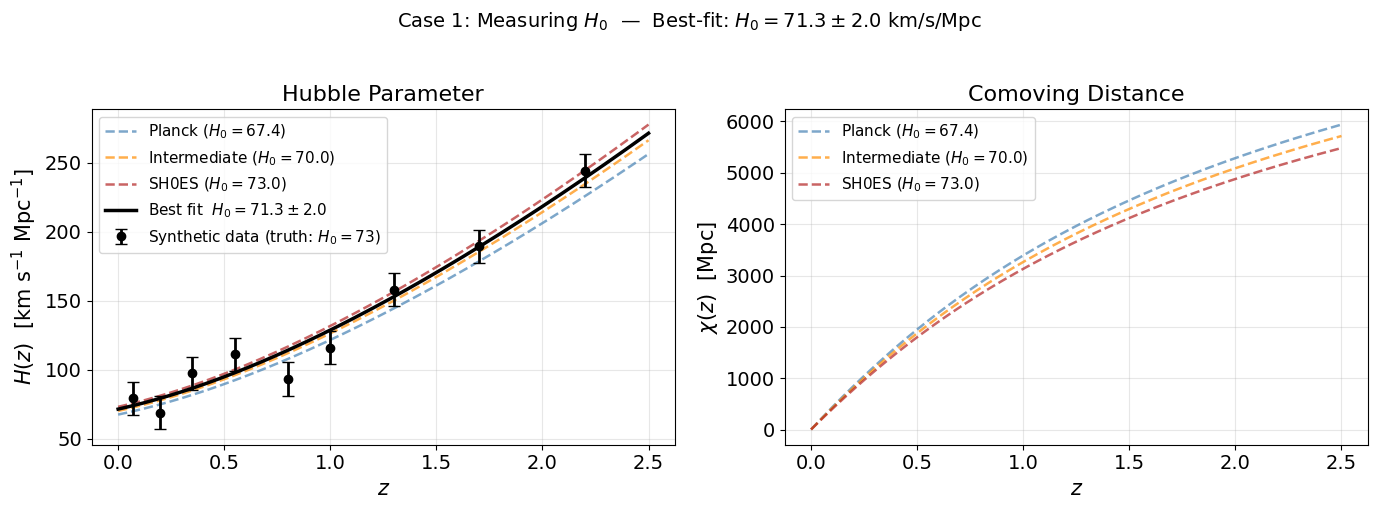

In [5]:
from scipy.optimize import curve_fit

# ── Redshift grid and theory curves ─────────────────────────────────────────
zs = np.linspace(1e-3, 2.5, 300)

H0_values = [67.37, 70.0, 73.0]          # Planck, intermediate, SH0ES-like
labels    = ['Planck ($H_0=67.4$)', 'Intermediate ($H_0=70.0$)', 'SH0ES ($H_0=73.0$)']
colors    = ['steelblue', 'darkorange', 'firebrick']

# Cache theory H(z) for each model
Hz_theory = {}
chi_theory = {}
for H0 in H0_values:
    bg = CAMBBackground(
        H0=H0, Omega_cdm0=0.27, Omega_b0=0.05,
        w0=-1, wa=0, Omega_k0=0.0,
        ns=0.966, As=2.1e-9, mnu=0.06,
        gamma_MG=0.545, N_mnu=1
    )
    Hz_theory[H0]  = bg.hubble_parameter(zs)
    chi_theory[H0] = bg.comoving_distance(zs)

# ── Synthetic "observed" data ─────────────────────────────────────────────────
# Pretend the true cosmology is SH0ES-like (H0=73); add noise to mimic data.
rng = np.random.default_rng(42)
z_obs    = np.array([0.07, 0.20, 0.35, 0.55, 0.80, 1.00, 1.30, 1.70, 2.20])
sigma_Hz = 12.0                               # 1-sigma uncertainty [km/s/Mpc]

bg_true  = CAMBBackground(
    H0=73.0, Omega_cdm0=0.27, Omega_b0=0.05,
    w0=-1, wa=0, Omega_k0=0.0,
    ns=0.966, As=2.1e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1
)
Hz_true_obs = bg_true.hubble_parameter(z_obs)
Hz_obs  = Hz_true_obs + rng.normal(0, sigma_Hz, size=len(z_obs))
dHz_obs = sigma_Hz * np.ones(len(z_obs))

# ── Fit H0 from the synthetic data ────────────────────────────────────────────
# Model: H(z; H0) = H0 * E(z)  where E(z) = H(z)/H0 from the fiducial shape
# We scale the Planck H(z)/H0 shape and fit H0 as a free parameter.
bg_planck = CAMBBackground(
    H0=67.37, Omega_cdm0=0.27, Omega_b0=0.05,
    w0=-1, wa=0, Omega_k0=0.0,
    ns=0.966, As=2.1e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1
)
Ez_shape = bg_planck.hubble_parameter(z_obs) / 67.37   # dimensionless E(z)

def Hz_model(z_dummy, H0_fit):
    return H0_fit * Ez_shape                           # scaled template

popt, pcov = curve_fit(Hz_model, z_obs, Hz_obs, p0=[70.0], sigma=dHz_obs, absolute_sigma=True)
H0_fit    = popt[0]
H0_fit_err = np.sqrt(pcov[0, 0])

Hz_bestfit = bg_planck.hubble_parameter(zs) / 67.37 * H0_fit

print(f'Best-fit H0 = {H0_fit:.2f} ± {H0_fit_err:.2f}  km/s/Mpc')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: H(z) with data and fit ---
for H0, color, lbl in zip(H0_values, colors, labels):
    axes[0].plot(zs, Hz_theory[H0], color=color, lw=1.8, ls='--', alpha=0.7, label=lbl)

axes[0].errorbar(z_obs, Hz_obs, yerr=dHz_obs, fmt='o', color='black',
                 ms=6, capsize=4, zorder=5, label='Synthetic data (truth: $H_0=73$)')
axes[0].plot(zs, Hz_bestfit, color='black', lw=2.5,
             label=f'Best fit  $H_0={H0_fit:.1f}\\pm{H0_fit_err:.1f}$')

axes[0].set(xlabel='$z$', ylabel='$H(z)$  [km s$^{-1}$ Mpc$^{-1}$]',
            title='Hubble Parameter')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- right: comoving distance ---
for H0, color, lbl in zip(H0_values, colors, labels):
    axes[1].plot(zs, chi_theory[H0], color=color, lw=1.8, ls='--', alpha=0.7, label=lbl)

axes[1].set(xlabel='$z$', ylabel='$\\chi(z)$  [Mpc]', title='Comoving Distance')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle(
    f'Case 1: Measuring $H_0$  —  Best-fit: $H_0 = {H0_fit:.1f} \\pm {H0_fit_err:.1f}$ km/s/Mpc',
    y=1.02, fontsize=14
)
plt.tight_layout()
plt.show()


---
## 2  Extracting $\Omega_b$ using BAOs

The BAO dilation parameters $\alpha_\perp$ and $\alpha_\parallel$ encode how the measured BAO scale compares to the fiducial one. They depend sensitively on the baryon density $\Omega_b$, which sets the sound horizon $r_d$ at the drag epoch. Here we scan $\Omega_b$ values and show how the ratio $r_{d,\rm fid}/r_d$ – and hence the alpha parameters – shifts.

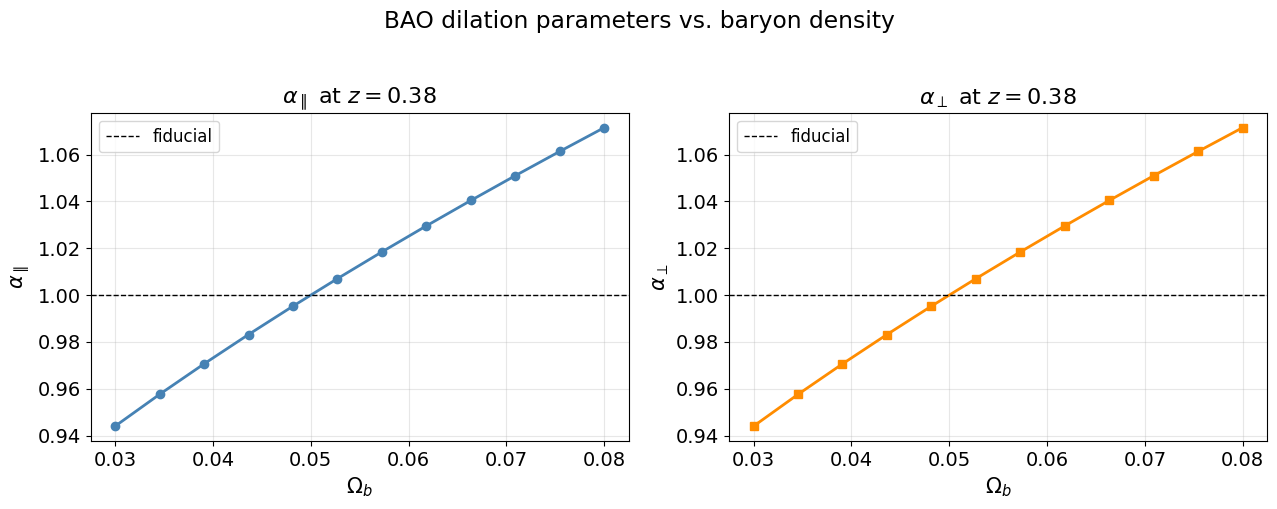

Fiducial r_drag = 146.08 Mpc


In [4]:
# Fiducial cosmology
bg_fid = CAMBBackground(
    H0=67.37, Omega_cdm0=0.27, Omega_b0=0.05,
    w0=-1, wa=0, Omega_k0=0.0,
    ns=0.966, As=2.1e-9, mnu=0.06,
    gamma_MG=0.545, N_mnu=1
)

z_bao  = np.array([0.38, 0.51, 0.70, 1.48])          # BAO survey effective redshifts
Omega_b_scan = np.linspace(0.03, 0.08, 12)

alpha_par_z0  = []
alpha_perp_z0 = []

for Ob in Omega_b_scan:
    bg_test = CAMBBackground(
        H0=67.37, Omega_cdm0=0.27 - (Ob - 0.05),  # keep Omega_m fixed
        Omega_b0=Ob,
        w0=-1, wa=0, Omega_k0=0.0,
        ns=0.966, As=2.1e-9, mnu=0.06,
        gamma_MG=0.545, N_mnu=1
    )
    bao = BaryonAcousticOscillations(bg_test, bg_fid, z_bao)
    alpha_par_z0.append(bao.alpha_par(z_bao[0]))
    alpha_perp_z0.append(bao.alpha_perp(z_bao[0]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(Omega_b_scan, alpha_par_z0, 'o-', color='steelblue')
axes[0].axhline(1.0, color='k', ls='--', lw=1, label='fiducial')
axes[0].set(xlabel='$\\Omega_b$', ylabel='$\\alpha_\\parallel$',
            title=f'$\\alpha_\\parallel$ at $z={z_bao[0]}$')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(Omega_b_scan, alpha_perp_z0, 's-', color='darkorange')
axes[1].axhline(1.0, color='k', ls='--', lw=1, label='fiducial')
axes[1].set(xlabel='$\\Omega_b$', ylabel='$\\alpha_\\perp$',
            title=f'$\\alpha_\\perp$ at $z={z_bao[0]}$')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('BAO dilation parameters vs. baryon density', y=1.02)
plt.tight_layout()
plt.show()

rd_fid = bg_fid.rdrag
print(f'Fiducial r_drag = {rd_fid:.2f} Mpc')

---
## 3  Calibrating Photometric Redshifts

Photo-$z$ calibration shifts ($\delta z$) and multiplicative biases ($\mu$) are crucial nuisance parameters for weak-lensing surveys. Here we build a simple synthetic $n(z)$ with multiple tomographic bins, apply per-bin $\delta z$ shifts using the `ShearTracer`, and visualise how the redshift distributions change.

Note: redshifts have been re-sorted (earliest first)


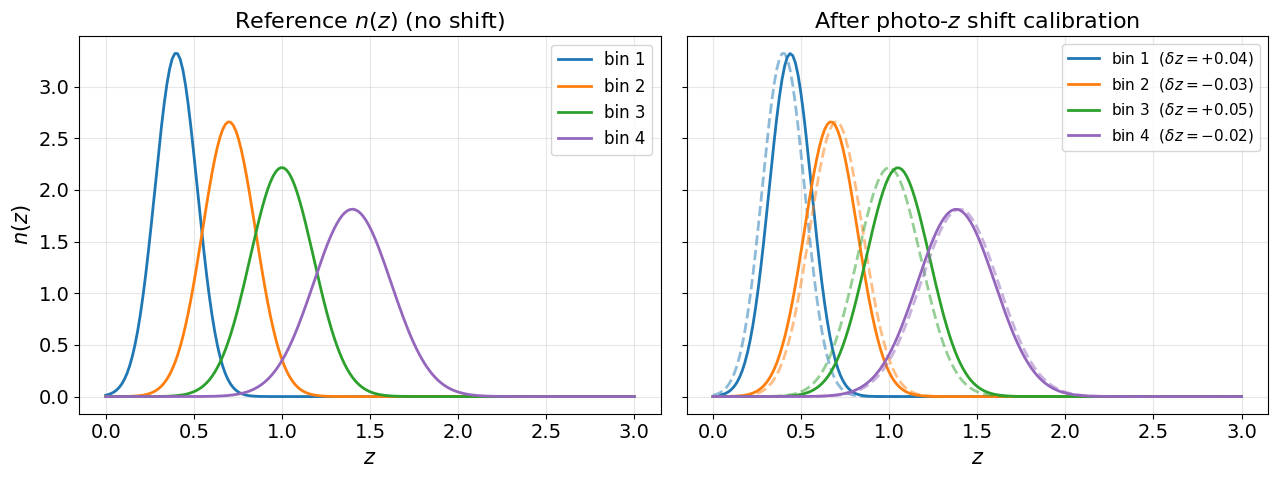

In [8]:
# ── Synthetic n(z): 4 Gaussian tomographic bins ──────────────────────────────
n_bins  = 4
z_phz   = np.linspace(1e-3, 3.0, 200)
z_means = [0.4, 0.7, 1.0, 1.4]
z_sigmas= [0.12, 0.15, 0.18, 0.22]

nz_raw = np.array([
    np.exp(-0.5 * ((z_phz - mu) / sig)**2)
    for mu, sig in zip(z_means, z_sigmas)
])

nz_norm = np.array([
    n / integrate.trapezoid(n, z_phz) for n in nz_raw
])

# ── Background cosmology + tracers ───────────────────────────────────────────
bg = CAMBBackground(
    H0=67.37, Omega_cdm0=0.27, Omega_b0=0.05,
    w0=-1, wa=0, Omega_k0=0.0, ns=0.966, As=2.1e-9,
    mnu=0.06, gamma_MG=0.545, N_mnu=1
)
lin = CAMBLinearPerturbations(bg, z_phz)

# Nuisance parameters — zero shifts (reference)
nu_ref = {
    'AIA': 0.16, 'CIA': 0.0134, 'EtaIA': -0.41,
    **{f'multiplicative_bias_{i+1}': 0.0 for i in range(n_bins)},
    **{f'dz_shear_{i+1}': 0.0 for i in range(n_bins)},
    **{f'width_shear_{i+1}': 1.0 for i in range(n_bins)},
}

# Nuisance parameters — representative photo-z shifts
dz_shifts = [0.04, -0.03, 0.05, -0.02]
nu_shift = {
    'AIA': 0.16, 'CIA': 0.0134, 'EtaIA': -0.41,
    **{f'multiplicative_bias_{i+1}': 0.0 for i in range(n_bins)},
    **{f'dz_shear_{i+1}': dz_shifts[i] for i in range(n_bins)},
    **{f'width_shear_{i+1}': 1.0 for i in range(n_bins)},
}

tracer_ref = ShearTracer(perturbations=lin, dndz=nz_norm, z=z_phz, nuisance_params=nu_ref)
tracer_shift = ShearTracer(perturbations=lin, dndz=nz_norm, z=z_phz, nuisance_params=nu_shift)

# ── Plot ─────────────────────────────────────────────────────────────────────
colors_bins = plt.cm.tab10(np.linspace(0, 0.4, n_bins))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for i in range(n_bins):
    axes[0].plot(z_phz, nz_norm[i], color=colors_bins[i], label=f'bin {i+1}')
    axes[1].plot(z_phz, nz_norm[i], color=colors_bins[i], ls='--', alpha=0.5)

    nz_shifted_i = np.interp(z_phz - dz_shifts[i], z_phz, nz_norm[i], left=0, right=0)
    nz_shifted_i /= integrate.trapezoid(nz_shifted_i, z_phz)
    axes[1].plot(
        z_phz, nz_shifted_i, color=colors_bins[i],
        label=f'bin {i+1}  ($\\delta z={dz_shifts[i]:+.2f}$)'
    )

axes[0].set(xlabel='$z$', ylabel='$n(z)$', title='Reference $n(z)$ (no shift)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set(xlabel='$z$', title='After photo-$z$ shift calibration')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4  Plotting Angular Power Spectra with cloelib

We compute the weak-lensing (EE) angular power spectra $C_\ell^{ij}$ for auto- and cross-correlations between tomographic bins using `AngularTwoPoint` from cloelib.

In [20]:
# ── Cosmology and n(z) ───────────────────────────────────────────────────────
n_bins_cl = 4
zs_cl     = np.linspace(1e-3, 3.0, 100)
z_means_cl = [0.4, 0.7, 1.0, 1.4]
z_sig_cl   = [0.12, 0.15, 0.18, 0.22]

nz_cl = np.array([
    np.exp(-0.5 * ((zs_cl - mu) / sig)**2)
    for mu, sig in zip(z_means_cl, z_sig_cl)
])
nz_cl = np.array([n / integrate.trapezoid(n, zs_cl) for n in nz_cl])

bg_cl = CAMBBackground(
    H0=67.37, Omega_cdm0=0.27, Omega_b0=0.05,
    w0=-1, wa=0, Omega_k0=0.0, ns=0.966, As=2.1e-9,
    mnu=0.06, gamma_MG=0.545, N_mnu=1
)
nl_cl = HMemuNonLinearPerturbations(
    bg_cl,
    HMemuLinearPerturbations(bg_cl, zs_cl),
    zs_cl,
    log10TAGN=7.8
)

nu_cl = {
    'AIA': 0.16, 'CIA': 0.0134, 'EtaIA': -0.41,
    **{f'multiplicative_bias_{i+1}': 0.0 for i in range(n_bins_cl)},
    **{f'dz_shear_{i+1}': 0.0 for i in range(n_bins_cl)},
    **{f'width_shear_{i+1}': 1.0 for i in range(n_bins_cl)},
}

tracer_she_cl = ShearTracer(
    perturbations=nl_cl,
    dndz=nz_cl,
    z=zs_cl,
    nuisance_params=nu_cl
)

# ── Compute Cells ─────────────────────────────────────────────────────────────
ells = np.geomspace(10, 3000, 40)
cells_she = AngularTwoPoint(tracer_she_cl, tracer_she_cl).get_Cl(ells, 0, nl_cl.k)

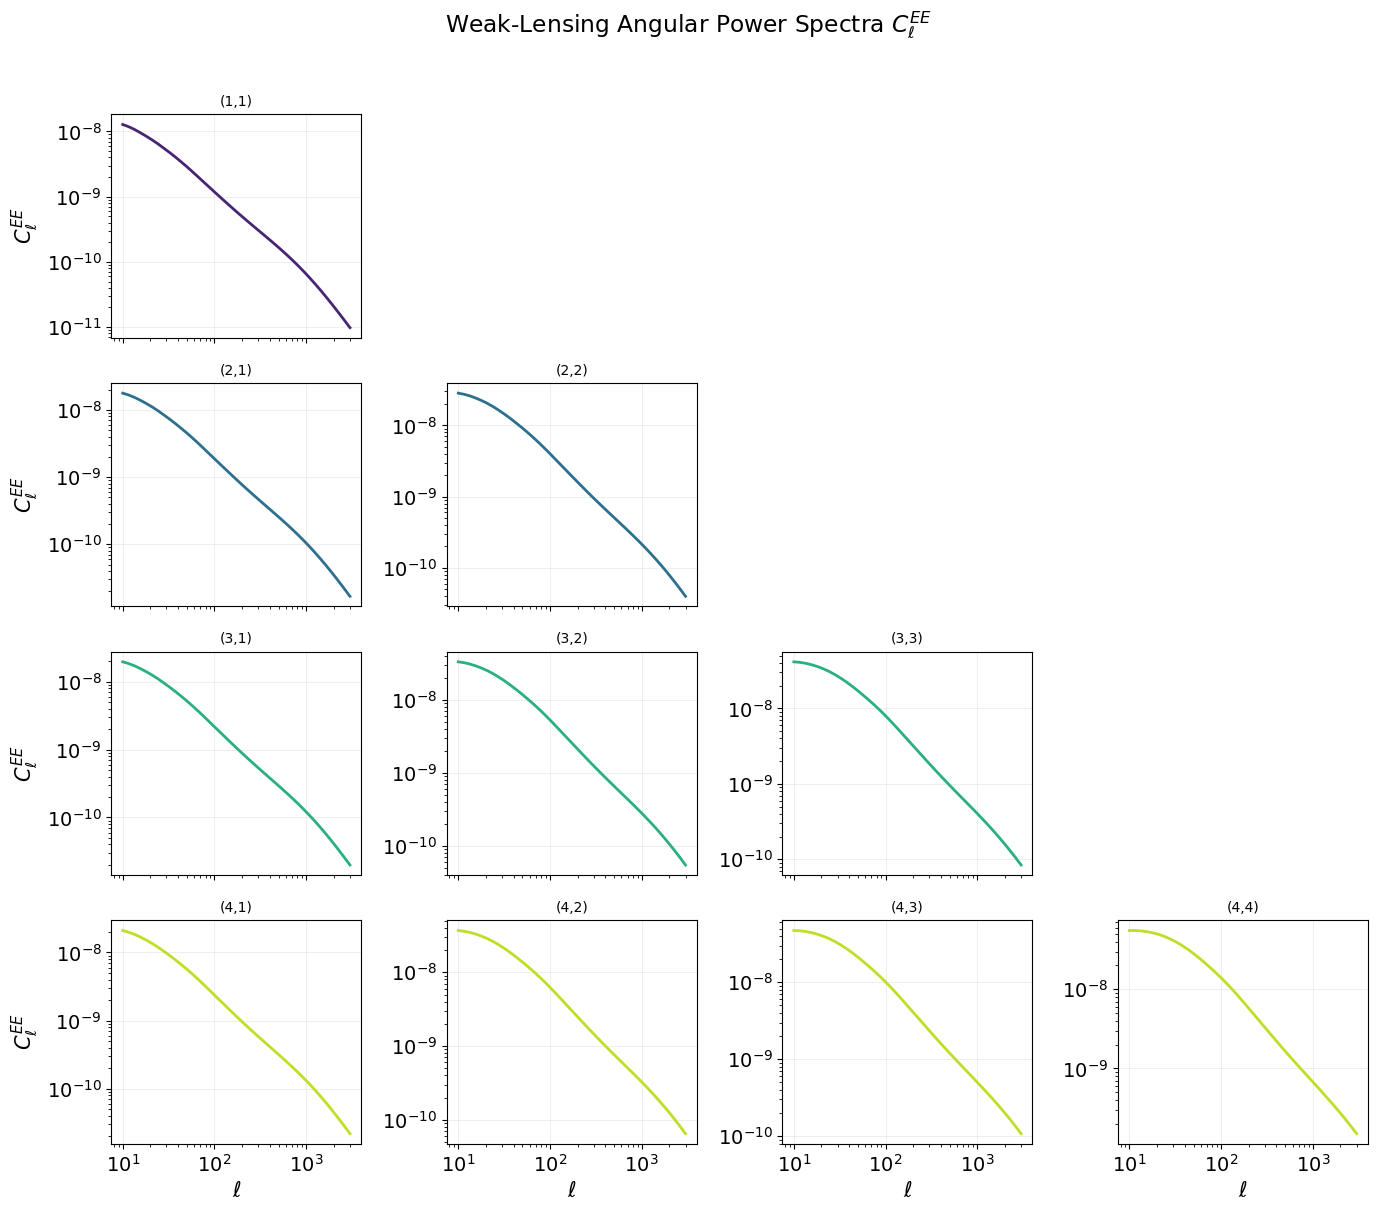

In [22]:
# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_bins_cl, n_bins_cl, figsize=(14, 12), sharex=True)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, n_bins_cl))

def get_cl_ij(cells, i_bin, j_bin):
    """
    Return C_ell for bin pair (i_bin, j_bin), robust to:
    - storage of only one triangle (i,j) or (j,i)
    - 1-based or 0-based bin indexing
    """
    trials = [
        (i_bin, j_bin), (j_bin, i_bin),         # 1-based direct/symmetric
        (i_bin - 1, j_bin - 1), (j_bin - 1, i_bin - 1)  # 0-based fallback
    ]
    for a, b in trials:
        try:
            return np.asarray(cells['SHE', 'SHE', a, b][0,0]).squeeze()
        except KeyError:
            pass
    raise KeyError(f"No SHE-SHE C_ell found for bins ({i_bin},{j_bin})")

for i in range(n_bins_cl):
    for j in range(n_bins_cl):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue

        cl_ij = get_cl_ij(cells_she, i + 1, j + 1)
        ax.loglog(ells, np.abs(cl_ij), color=cmap[max(i, j)])
        ax.set_title(f'({i+1},{j+1})', fontsize=10)
        ax.grid(alpha=0.2)

        if i == n_bins_cl - 1:
            ax.set_xlabel('$\\ell$')
        if j == 0:
            ax.set_ylabel('$C_\\ell^{EE}$')

plt.suptitle('Weak-Lensing Angular Power Spectra $C_\\ell^{EE}$', y=1.01)
plt.tight_layout()
plt.show()

---
## 5  Statistical Significance of COSEBIs B-modes

COSEBIs (Complete Orthogonal Sets of E/B-Integrals) provide a clean E/B decomposition of the weak-lensing signal on a finite angular range. Idealised B-modes should vanish — any non-zero measurement indicates systematic contamination. Here we:

1. Compute the COSEBI filter functions $W_n(\ell)$.
2. Project a toy B-mode power spectrum (and a noise realisation) onto COSEBI modes.
3. Perform a $\chi^2$ test to quantify the statistical significance of the B-modes.

In [ ]:
# ── COSEBI configuration ─────────────────────────────────────────────────────
nmax     = 8                                  # number of COSEBI modes
th_min, th_max = 0.5, 300.0                   # angular range [arcmin]
ells_int = np.arange(2, 20001)                # multipoles for integration
theta_rad = np.geomspace(th_min, th_max, int(5e4)) * np.pi / 10800.0

print('Computing COSEBI filter functions W_n(ell)…')
well = get_W_ell(theta_rad, nmax, ells_int, N_thread=4)
print(f'W_n shape: {well.shape}  (modes × ells)')

Computing COSEBI filter functions W_n(ell)…
start calculating roots and norms:
done
start evaluating kernels
start performing the bessel integrals (batched over all modes)


In [ ]:
# ── Toy B-mode power spectrum ────────────────────────────────────────────────
# A small residual systematic leaking ~1% of the EE signal into BB
A_sys  = 1e-8  # amplitude
Cl_BB  = A_sys * (ells_int / 100.0)**(-0.5)

# ── Gaussian noise covariance (diagonal approximation) ───────────────────────
# Euclid-like: n_eff ~ 30 gal/arcmin^2, sigma_e ~ 0.26
n_eff   = 30.0 * (180.0 * 60.0 / np.pi)**2   # convert to sr^-1
sigma_e = 0.26
f_sky   = 0.35
Cl_noise = sigma_e**2 / n_eff * np.ones_like(ells_int, dtype=float)

# ── Project onto COSEBI modes ─────────────────────────────────────────────────
def project_to_cosebis(Cl, well, ells):
    """Integrate ell * Cl * W_n(ell) over ell for each mode n."""
    n_modes = well.shape[0]
    Bn = np.zeros(n_modes)
    for n in range(n_modes):
        Bn[n] = integrate.simpson(ells * Cl * well[n], x=ells)
    return Bn / (2 * np.pi)

B_modes  = project_to_cosebis(Cl_BB,    well, ells_int)
N_modes  = project_to_cosebis(Cl_noise, well, ells_int)

# ── Estimate noise variance of the COSEBI estimator ──────────────────────────
# Approximate variance per mode: var(B_n) ~ (Cl_BB + Cl_noise)^2 integrated
# via the Fisher matrix diagonal  (delta_Cl ~ sqrt(2/(2l+1)f_sky) * Cl)
def cosebi_variance(Cl_tot, well, ells, f_sky):
    n_modes = well.shape[0]
    var = np.zeros(n_modes)
    delta_Cl2 = 2.0 / ((2.0 * ells + 1.0) * f_sky) * Cl_tot**2
    for n in range(n_modes):
        integrand = ells**2 * well[n]**2 * delta_Cl2
        var[n] = integrate.simpson(integrand, x=ells)
    return var / (2 * np.pi)**2

Cl_tot = Cl_BB + Cl_noise
var_B  = cosebi_variance(Cl_tot, well, ells_int, f_sky)
sigma_B = np.sqrt(var_B)

# ── chi-squared test ──────────────────────────────────────────────────────────
chi2 = np.sum((B_modes / sigma_B)**2)
dof  = nmax
p_value = 1.0 - stats.chi2.cdf(chi2, df=dof)
sigma_significance = stats.norm.isf(p_value / 2.0)

print(f'chi² = {chi2:.2f}  (dof = {dof})')
print(f'p-value = {p_value:.4g}')
print(f'Significance ≈ {sigma_significance:.2f} sigma')

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────────
modes = np.arange(1, nmax + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: B_n values with error bars
axes[0].errorbar(modes, B_modes, yerr=sigma_B, fmt='o', color='steelblue',
                 capsize=4, label='$B_n$')
axes[0].axhline(0, color='k', lw=1, ls='--')
axes[0].set(xlabel='COSEBI mode $n$', ylabel='$B_n$',
            title='COSEBI B-mode amplitudes',
            xticks=modes)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: cumulative chi-squared vs. number of modes
chi2_cumul = np.cumsum((B_modes / sigma_B)**2)
axes[1].plot(modes, chi2_cumul, 'o-', color='firebrick', label='cumulative $\\chi^2$')
axes[1].plot(modes, modes, 'k--', lw=1, label='$\\chi^2 = $ dof (expected)')
axes[1].set(xlabel='Number of modes', ylabel='Cumulative $\\chi^2$',
            title='Cumulative $\\chi^2$ of B-modes',
            xticks=modes)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    f'B-mode significance: $\\chi^2={chi2:.1f}$ / {dof} dof  →  '
    f'$p={p_value:.3f}$  ({sigma_significance:.1f}$\\sigma$)',
    y=1.02
)
plt.tight_layout()
plt.show()